# Rapport : Projet Analyse de Données
### BAFALUY Inés - GAYRAUD Julien - .... Valentino
##### 4A MA - 2026

## INTRODUCTION

Crée en 2008, Spotify est devenu la plateforme d'audio de streaming la plus populaire au monde, avec 751 million d'utilisateurs et plus de 100 million de pistes audios. Pour rester la plateforme de réference, Spotify doit étudier les tendences musicales actuelles pour proposer des services innovateurs et personnalisés. 
Recommandation de chansons, compréhension des tendences temporelles, détection de facteurs de succès

C'est dans ce cadre là, qu'à travers ce projet nous allons analyser un échantillon de leur base de données. Après avoir prétraité les données (1), nous allons étudier l'évolution des tendences temporelles (2), analyser les ressemblances inter et intra genres (3), identifier des facteurs de succès (4) et créer des playlists et recommandations adaptées (5). Avec les résultats de nos analyses, nous présenterons des indications d'actions concrètes à mettre en place pour que Spotify reste la plateforme de réference concurrente et attractive dans l'industrie musicale en ligne. 

REFORUMULATION CHAT

Créée en 2008, Spotify s’est imposée comme la plateforme de streaming audio la plus populaire au monde, avec 751 millions d’utilisateurs et plus de 100 millions de titres disponibles. Pour conserver sa position de référence, l’entreprise doit analyser les tendances musicales actuelles afin de proposer des services toujours plus innovants et personnalisés.

Recommandation de chansons, compréhension des évolutions temporelles des tendances, identification des facteurs de succès : ces enjeux sont au cœur de ce projet. À travers l’analyse d’un échantillon de la base de données de Spotify, nous commencerons par prétraiter les données (1), puis nous étudierons l’évolution des tendances au fil du temps (2), les similarités inter- et intra-genres (3), les déterminants du succès musical (4), avant de concevoir des playlists et des recommandations adaptées (5).

À partir des résultats obtenus, nous formulerons des pistes d’action concrètes permettant à Spotify de renforcer durablement son attractivité et de demeurer une plateforme de référence, compétitive dans l’industrie du streaming musical.


## I. Exploration des données

#### IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import prince
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import scale

import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
from sklearn.preprocessing import scale

from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score 


### 1. Base de données

#### Aperçu des données brutes

In [1]:
# Load the latest version
data_initial = pd.read_csv('data/spotify_songs.csv')

NameError: name 'pd' is not defined

#### Taille

In [ ]:
#Taille du jeu de données : 33k lignes et 23 clonnes qu on affiche
print(data_initial.shape)
print(data_initial.columns)

(32833, 23)
Index(['track_id', 'track_name', 'track_artist', 'track_popularity',
       'track_album_id', 'track_album_name', 'track_album_release_date',
       'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms'],
      dtype='str')


#### Qualitative

In [ ]:
# Variables qualitives
qual_cols = data_initial.select_dtypes(include=['object']).columns
print('Variables qualitatives :', list(qual_cols))

Variables qualitatives : ['track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre']


C:\Users\alexb\AppData\Local\Temp\ipykernel_26944\121485315.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  qual_cols = data_initial.select_dtypes(include=['object']).columns


In [ ]:
categorical_cols = [
    "playlist_name", 
    "playlist_genre", 
    "playlist_subgenre",
    "mode",
    "key"
]

for col in categorical_cols:
    data_initial[col] = pd.Categorical(data_initial[col], ordered=False)

data_initial.describe()


,track_popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,-6.719499,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,2.988436,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,-8.171000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,-6.166000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,-4.645000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,1.275000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


#### Quantitative

In [ ]:
# Variables quantatives
quant_cols = data_initial.select_dtypes(include=['float64', 'int64']).columns
print('Variables quantitatives :', list(quant_cols))

Variables quantitatives : ['track_popularity', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']


In [ ]:
print(data_initial[categorical_cols].describe())

          playlist_name playlist_genre          playlist_subgenre   mode  \
count             32833          32833                      32833  32833   
unique              449              6                         24      2   
top     Indie Poptimism            edm  progressive electro house      1   
freq                308           6043                       1809  18574   

          key  
count   32833  
unique     12  
top         1  
freq     4010  


#### CLEAN DATA

In [ ]:
# Remove dumb columns and uncomplete lines 

print('=== Non-meaningful columns ===')
# remove identifiers if they exist
cols = ["track_album_id", "playlist_id"]
print('Columns to drop:', cols)
data_initial.drop(columns=cols, errors='ignore', inplace=True)

print('')
print('=== Missing values ===')
print('Columns containing missing values are:', list(data_initial.columns[data_initial.isnull().sum()!=0]))

print('')
print('track_name - Rate of missing values: {:.2f}%'.format(data_initial['track_name'].isnull().sum()/data_initial.shape[0]*100))
print('track_artist - Rate of missing values: {:.2f}%'.format(data_initial['track_artist'].isnull().sum()/data_initial.shape[0]*100))
print('track_album_name - Rate of missing values: {:.2f}%'.format(data_initial['track_album_name'].isnull().sum()/data_initial.shape[0]*100))

print('We cannot put the average value or the most common value and the rate of missing values is very low, hence we will just delete the rows that have empty data.')

data = data_initial.dropna(subset=['track_name', 'track_artist', 'track_album_name'])

print('')
print('=== Checking ===')
print('Columns containing missing values are:', list(data.columns[data.isnull().sum()!=0]))


=== Non-meaningful columns ===
Columns to drop: ['track_album_id', 'playlist_id']

=== Missing values ===
Columns containing missing values are: ['track_name', 'track_artist', 'track_album_name']

track_name - Rate of missing values: 0.02%
track_artist - Rate of missing values: 0.02%
track_album_name - Rate of missing values: 0.02%
We cannot put the average value or the most common value and the rate of missing values is very low, hence we will just delete the rows that have empty data.

=== Checking ===
Columns containing missing values are: []


#### Normalisation

In [ ]:
data_centered = data.copy()
data_centered[quant_cols] = scale(data[quant_cols])

C:\Users\alexb\AppData\Local\Temp\ipykernel_26944\4982838.py:4: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data[quant_cols].hist(bins=30,


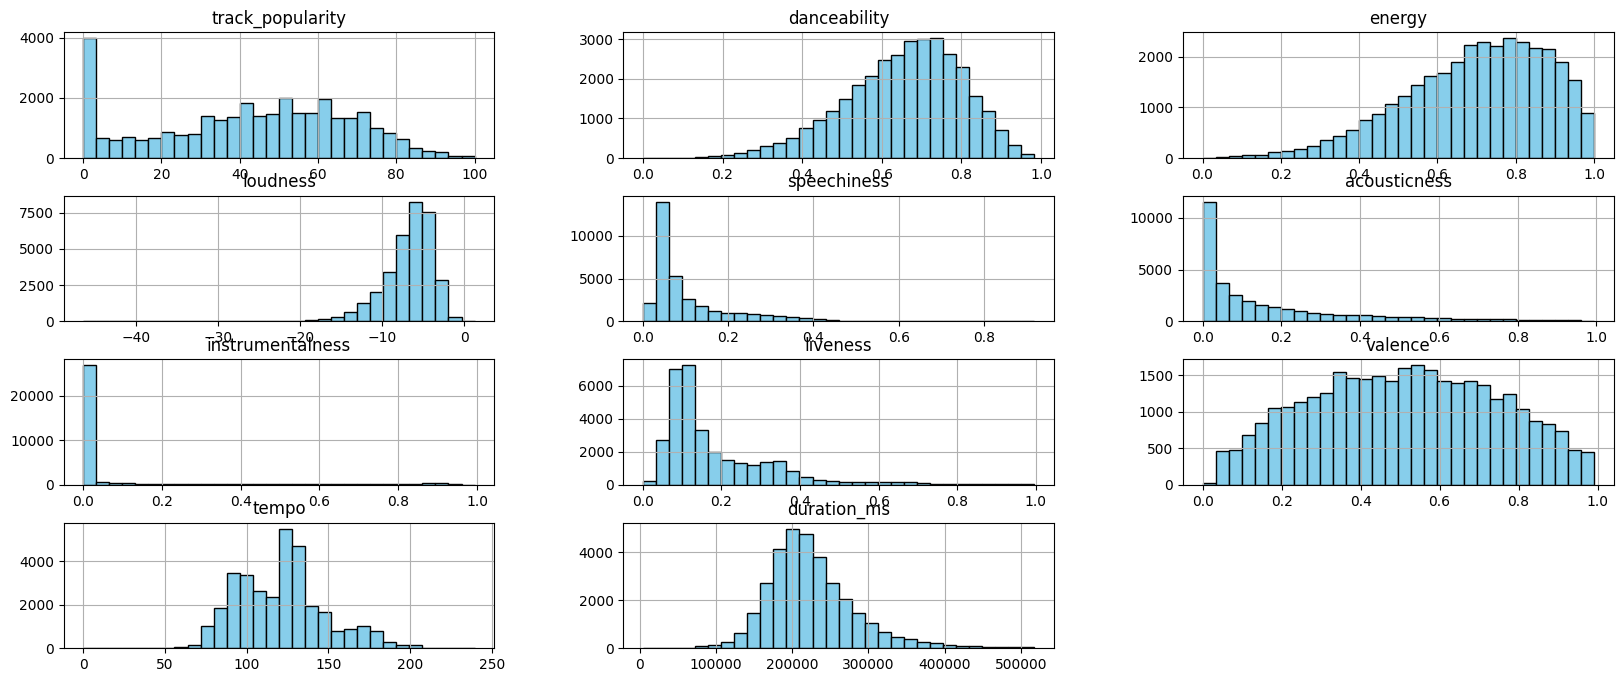

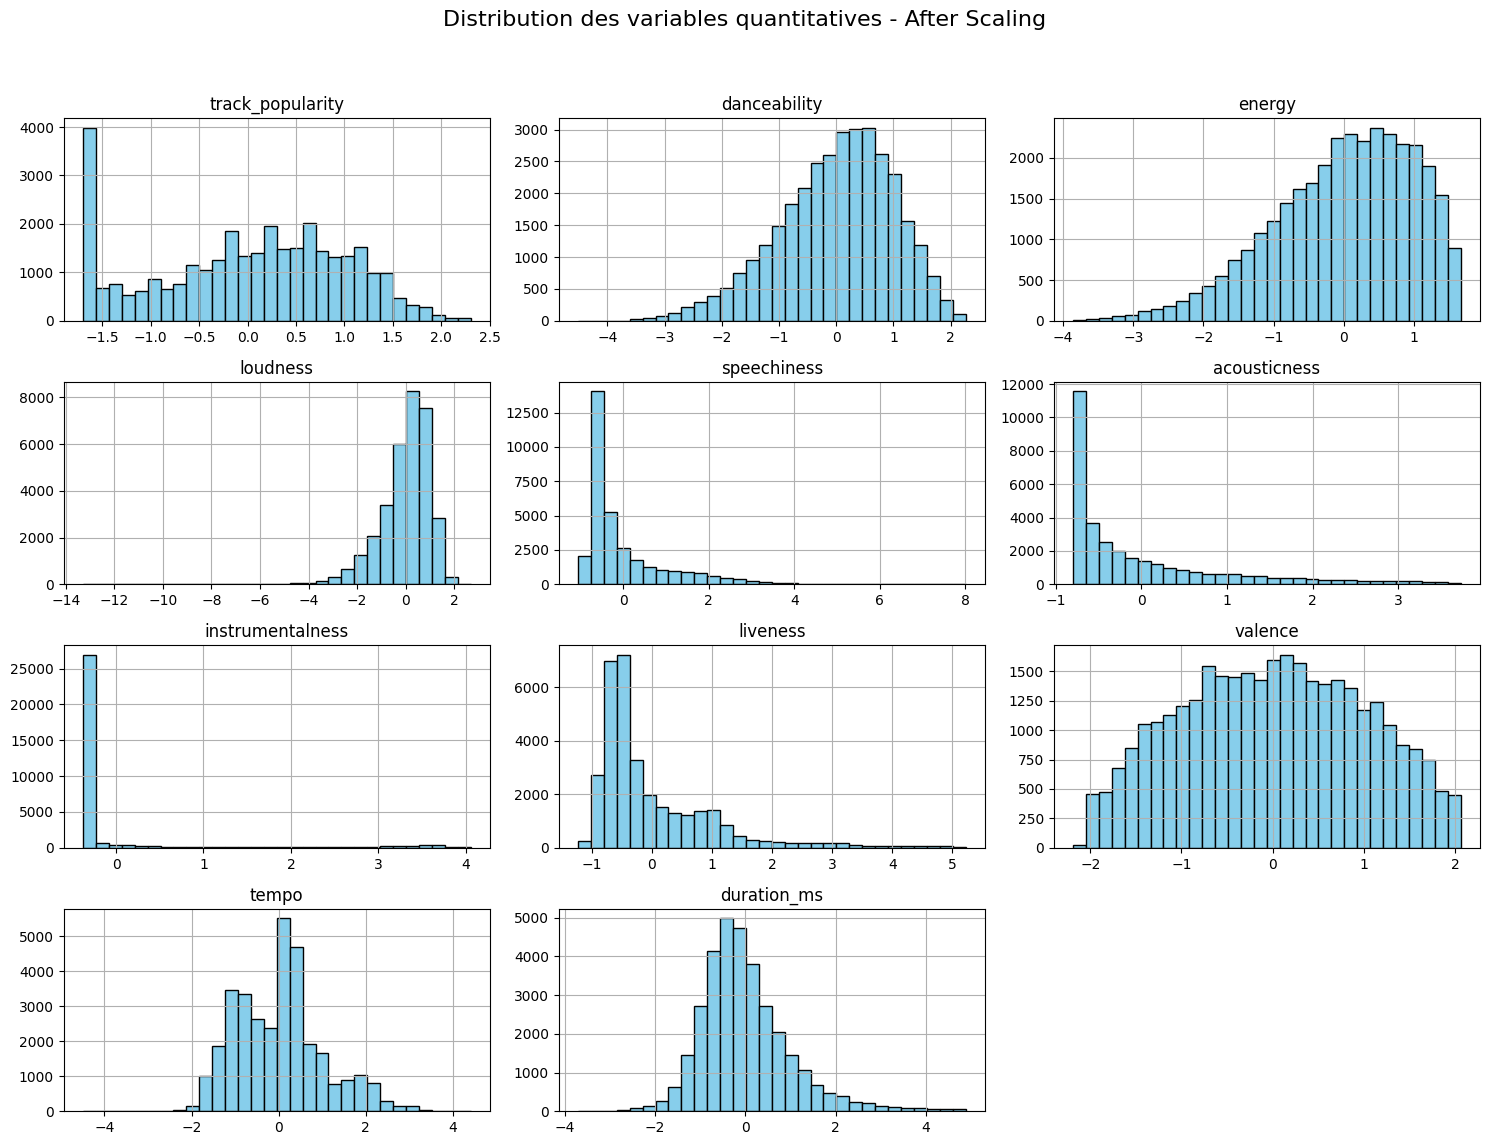

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# before scaling
data[quant_cols].hist(bins=30,
                      ax=axes[0],
                      color='skyblue',
                      edgecolor='black')
axes[0].set_title("Distribution des variables quantitatives\nBefore Scaling",
                  fontsize=14)

# After scaling
data_centered[quant_cols].hist(bins=30, figsize=(15, 12), color='skyblue', edgecolor='black')
plt.suptitle("Distribution des variables quantitatives - After Scaling", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### Normalizing ----------------------- on ne normalise pas finalement non?

#### OUTLIERS


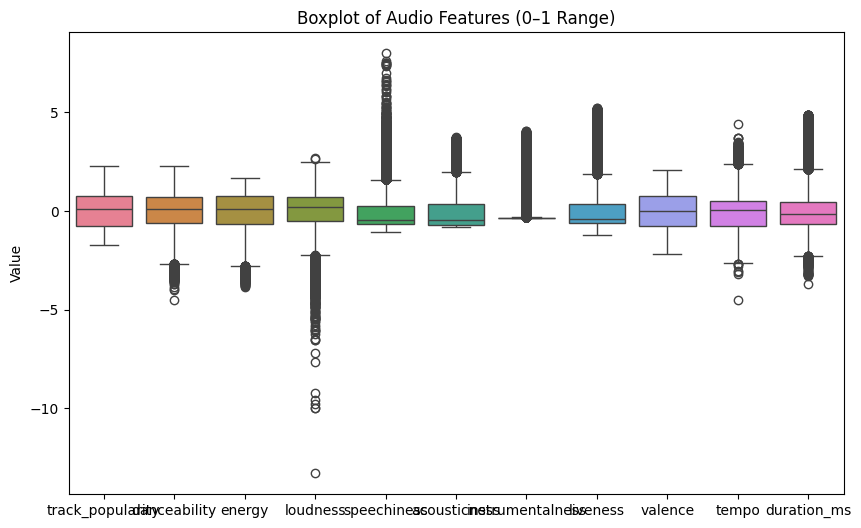

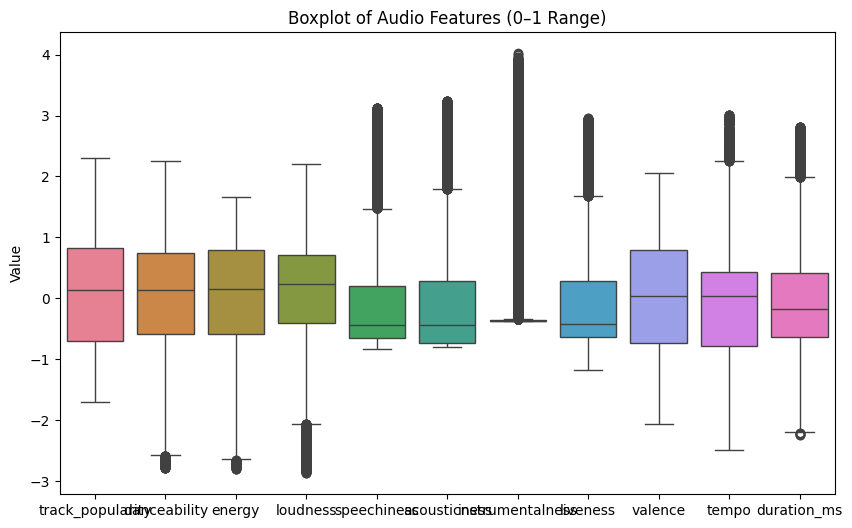


=== OUTLIER REMOVAL SUMMARY ===

Before outlier removal: 32828 rows
After outlier removal: 29827 rows
Rows removed: 3001 (9.14%)


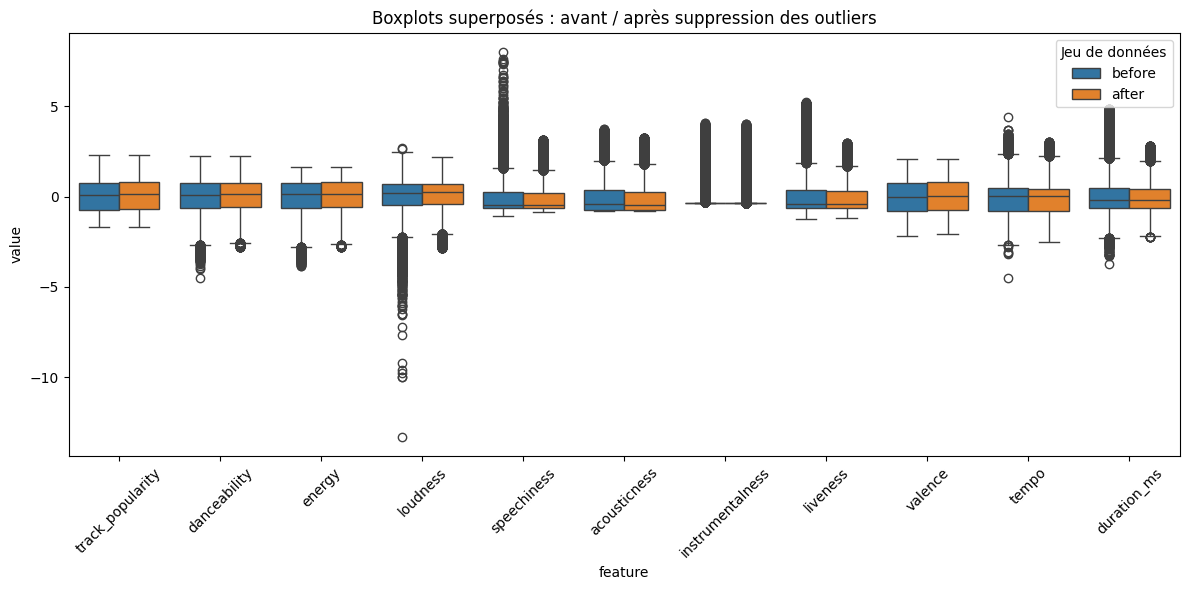

In [ ]:
## BOXPLOTS

# on souhaite détécter les outliers qui contiennent des valeur numériques extrêmes

# variables numériques
quant_cols = data.select_dtypes(include='number').columns.tolist()

# on supprime les variables mode et key car elles sont quantitatives
if 'mode' in quant_cols:
    quant_cols.remove('mode')
if 'key' in quant_cols:
    quant_cols.remove('key')

# on les ramène à une échelle comparable (notamment pour duration_ms)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data[quant_cols] = scaler.fit_transform(data[quant_cols])

# PLOT
plt.figure(figsize=(10,6))
sns.boxplot(data=data[quant_cols])
plt.title("Boxplot of Audio Features (0–1 Range)")
plt.ylabel("Value")
plt.show()

## Remove data below 5th percentile and above 95th percentile
k=0.3
difference = data[quant_cols].quantile(0.95) - data[quant_cols].quantile(0.05)
lower_bounds = data[quant_cols].quantile(0.05) - k*difference
upper_bounds = data[quant_cols].quantile(0.95) + k*difference

mask = np.ones(len(data), dtype=bool)

for col in quant_cols:
    mask &= (data[col] >= lower_bounds[col]) & (data[col] <= upper_bounds[col])

data_without_outliers = data[mask]


## BOXPLOTS AFTER CLEANING
plt.figure(figsize=(10,6))
sns.boxplot(data=data_without_outliers[quant_cols])
plt.title("Boxplot of Audio Features (0–1 Range)")
plt.ylabel("Value")
plt.show()

# Print summary statistics before and after outlier removal
print("\n=== OUTLIER REMOVAL SUMMARY ===")
print(f"\nBefore outlier removal: {len(data)} rows")
print(f"After outlier removal: {len(data_without_outliers)} rows")
print(f"Rows removed: {len(data) - len(data_without_outliers)} ({(len(data) - len(data_without_outliers))/len(data)*100:.2f}%)")


# on construit un jeu de données long qui contient
# les deux versions (avant / après nettoyage)
df_before = data[quant_cols].copy()
df_before['dataset'] = 'before'
df_after = data_without_outliers[quant_cols].copy()
df_after['dataset'] = 'after'

df_comb = pd.concat([df_before, df_after], ignore_index=True)
df_comb = df_comb.melt(id_vars='dataset',
                       var_name='feature',
                       value_name='value')

plt.figure(figsize=(12, 6))
sns.boxplot(x='feature', y='value', hue='dataset', data=df_comb)
plt.xticks(rotation=45)
plt.title('Boxplots superposés : avant / après suppression des outliers')
plt.legend(title='Jeu de données')
plt.tight_layout()
plt.show()



In [ ]:
df_clean=data_without_outliers.copy()

### 2. Etude des variables

### 3. Etude des corrélations entre variables

## II. Analyse des tendences (TEMPS)

## III. Analyse des genres

## IV. Analyse des facteurs de succès

## V. Création de playlists

## CONCLUSION